<a href="https://www.kaggle.com/code/sonawanelalitsunil/attack-on-titan-ml-82-38?scriptVersionId=250428524" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/top-popular-anime/popular_anime.csv


## Title:
Attack on Titan

## Description

A dark, action-packed saga where humanity fights monstrous Titans.
Set in a world overrun by giant humanoid creatures called Titans, this anime follows Eren Yeager and his friends as they uncover the truth behind the Titans and their walled society. Known for its intense action, deep lore, and dramatic twists.



## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/top-popular-anime/popular_anime.csv')


In [3]:
df.head()

,id,name,genres,type,episodes,status,aired_from,aired_to,duration_per_ep,score,scored_by,rank,rating,studios,producers,image,trailer,synopsis
0,52991,Frieren: Beyond Journey's End,"Adventure, Drama, Fantasy",TV,28.0,Finished Airing,2023-09-29T00:00:00+00:00,2024-03-22T00:00:00+00:00,24 min per ep,9.30,676737.0,1.0,PG-13 - Teens 13 or older,Madhouse,"Aniplex, Dentsu, Shogakukan-Shueisha Productio...",https://cdn.myanimelist.net/images/anime/1015/...,https://www.youtube.com/watch?v=ZEkwCGJ3o7M,During their decade-long quest to defeat the D...
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy",TV,64.0,Finished Airing,2009-04-05T00:00:00+00:00,2010-07-04T00:00:00+00:00,24 min per ep,9.10,2223666.0,2.0,R - 17+ (violence & profanity),Bones,"Aniplex, Square Enix, Mainichi Broadcasting Sy...",https://cdn.myanimelist.net/images/anime/1208/...,https://www.youtube.com/watch?v=1ac3_YdSSy0,After a horrific alchemy experiment goes wrong...
2,9253,Steins;Gate,"Drama, Sci-Fi, Suspense",TV,24.0,Finished Airing,2011-04-06T00:00:00+00:00,2011-09-14T00:00:00+00:00,24 min per ep,9.07,1467570.0,3.0,PG-13 - Teens 13 or older,White Fox,"Frontier Works, Media Factory, Kadokawa Shoten...",https://cdn.myanimelist.net/images/anime/1935/...,https://www.youtube.com/watch?v=27OZc-ku6is,Eccentric scientist Rintarou Okabe has a never...
3,38524,Attack on Titan Season 3 Part 2,"Action, Drama, Suspense",TV,10.0,Finished Airing,2019-04-29T00:00:00+00:00,2019-07-01T00:00:00+00:00,23 min per ep,9.05,1700946.0,4.0,R - 17+ (violence & profanity),Wit Studio,"Production I.G, Dentsu, Mainichi Broadcasting ...",https://cdn.myanimelist.net/images/anime/1517/...,https://www.youtube.com/watch?v=hKHepjfj5Tw,Seeking to restore humanity's diminishing hope...
4,28977,Gintama Season 4,"Action, Comedy, Sci-Fi",TV,51.0,Finished Airing,2015-04-08T00:00:00+00:00,2016-03-30T00:00:00+00:00,24 min per ep,9.05,264260.0,5.0,PG-13 - Teens 13 or older,Bandai Namco Pictures,"TV Tokyo, Aniplex, Dentsu",https://cdn.myanimelist.net/images/anime/3/720...,NaN,"Gintoki, Shinpachi, and Kagura return as the f..."


In [4]:
df.tail()

,id,name,genres,type,episodes,status,aired_from,aired_to,duration_per_ep,score,scored_by,rank,rating,studios,producers,image,trailer,synopsis
28820,16796,Mujeokcheorin Rambot,"Action, Sci-Fi",Movie,1.0,Finished Airing,1985-01-01T00:00:00+00:00,NaN,1 hr 10 min,NaN,NaN,18282.0,NaN,NaN,NaN,https://cdn.myanimelist.net/images/anime/5/451...,NaN,NaN
28821,48866,Hua Jianghu: Huan Shi Men Sheng 2nd Season,"Drama, Fantasy, Mystery, Romance",ONA,19.0,Finished Airing,2021-05-12T00:00:00+00:00,2021-08-25T00:00:00+00:00,20 min per ep,NaN,NaN,21550.0,PG-13 - Teens 13 or older,Rocen,NaN,https://cdn.myanimelist.net/images/anime/1037/...,NaN,Second season of Hua Ji
28822,16790,Super Samchongsa,"Action, Sci-Fi",Movie,1.0,Finished Airing,1982-01-01T00:00:00+00:00,NaN,1 hr 16 min,NaN,NaN,14907.0,NaN,NaN,NaN,https://cdn.myanimelist.net/images/anime/13/45...,NaN,A Korean animated movie about three kids prote...
28823,16788,Sengoku Bushou Retsuden Bakufuu Douji Hissatsuman,"Action, Adventure",OVA,3.0,Finished Airing,1990-06-22T00:00:00+00:00,1990-10-25T00:00:00+00:00,35 min per ep,NaN,NaN,14261.0,R+ - Mild Nudity,NaN,"Bandai Visual, Artmic",https://cdn.myanimelist.net/images/anime/11/45...,NaN,NaN
28824,16784,Marin X,"Action, Adventure, Sci-Fi",Movie,1.0,Finished Airing,1982-01-01T00:00:00+00:00,NaN,1 hr 20 min,NaN,NaN,17871.0,NaN,NaN,NaN,https://cdn.myanimelist.net/images/anime/13/45...,NaN,A Korean animated movie mixing Mecha w


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28825 entries, 0 to 28824
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               28825 non-null  int64  
 1   name             28825 non-null  object 
 2   genres           22756 non-null  object 
 3   type             28738 non-null  object 
 4   episodes         28046 non-null  float64
 5   status           28825 non-null  object 
 6   aired_from       27870 non-null  object 
 7   aired_to         10930 non-null  object 
 8   duration_per_ep  28825 non-null  object 
 9   score            18599 non-null  float64
 10  scored_by        18599 non-null  float64
 11  rank             21962 non-null  float64
 12  rating           28101 non-null  object 
 13  studios          16936 non-null  object 
 14  producers        13452 non-null  object 
 15  image            28825 non-null  object 
 16  trailer          5474 non-null   object 
 17  synopsis    

In [6]:
df.describe()

,id,episodes,score,scored_by,rank
count,28825.000000,28046.000000,18599.000000,1.859900e+04,21962.000000
mean,34131.945117,13.827462,6.397697,2.989163e+04,10522.959749
std,19617.957463,46.841239,0.889835,1.212973e+05,6386.404388
min,1.000000,1.000000,1.890000,1.010000e+02,0.000000
25%,15979.000000,1.000000,5.780000,3.400000e+02,4989.250000
50%,38070.000000,2.000000,6.370000,1.544000e+03,10462.500000
75%,51060.000000,13.000000,7.030000,1.009150e+04,16022.750000
max,61871.000000,3057.000000,9.300000,2.943048e+06,21729.000000


In [7]:
df.isnull().sum()

id                     0
name                   0
genres              6069
type                  87
episodes             779
status                 0
aired_from           955
aired_to           17895
duration_per_ep        0
score              10226
scored_by          10226
rank                6863
rating               724
studios            11889
producers          15373
image                  0
trailer            23351
synopsis            5368
dtype: int64

In [8]:
df.duplicated().sum()

218

In [9]:
df.dtypes

id                   int64
name                object
genres              object
type                object
episodes           float64
status              object
aired_from          object
aired_to            object
duration_per_ep     object
score              float64
scored_by          float64
rank               float64
rating              object
studios             object
producers           object
image               object
trailer             object
synopsis            object
dtype: object

In [10]:
df.shape

(28825, 18)

In [11]:
df.columns

Index(['id', 'name', 'genres', 'type', 'episodes', 'status', 'aired_from',
       'aired_to', 'duration_per_ep', 'score', 'scored_by', 'rank', 'rating',
       'studios', 'producers', 'image', 'trailer', 'synopsis'],
      dtype='object')

## Data visualizations

<Figure size 1200x600 with 0 Axes>

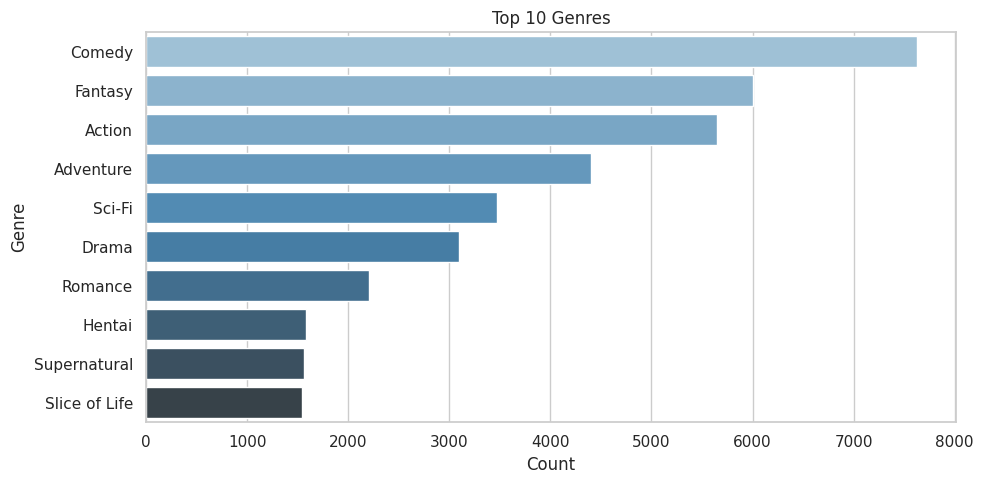

In [12]:
# Set visual style
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))

# -------------------- 1. Top Genres --------------------
# Split genre strings and explode
genre_series = df['genres'].dropna().str.split(', ').explode()
top_genres = genre_series.value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='Blues_d')
plt.title('Top 10 Genres')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()


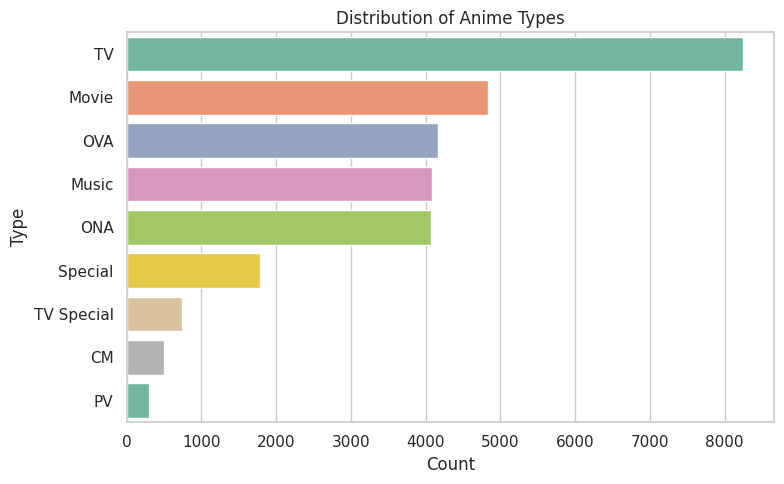

In [13]:
# -------------------- 2. Type of Anime --------------------
plt.figure(figsize=(8, 5))
sns.countplot(data=df, y='type', order=df['type'].value_counts().index, palette='Set2')
plt.title('Distribution of Anime Types')
plt.xlabel('Count')
plt.ylabel('Type')
plt.tight_layout()
plt.show()


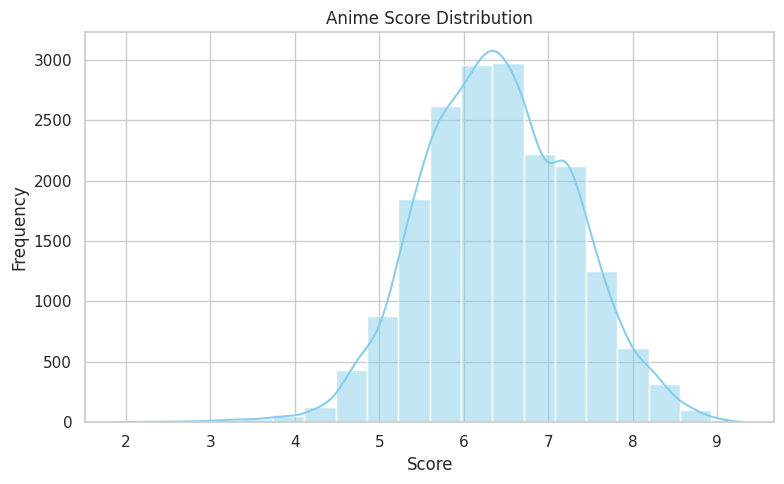

In [14]:
# -------------------- 3. Score Distribution --------------------
plt.figure(figsize=(8, 5))
sns.histplot(df['score'].dropna(), bins=20, kde=True, color='skyblue')
plt.title('Anime Score Distribution')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

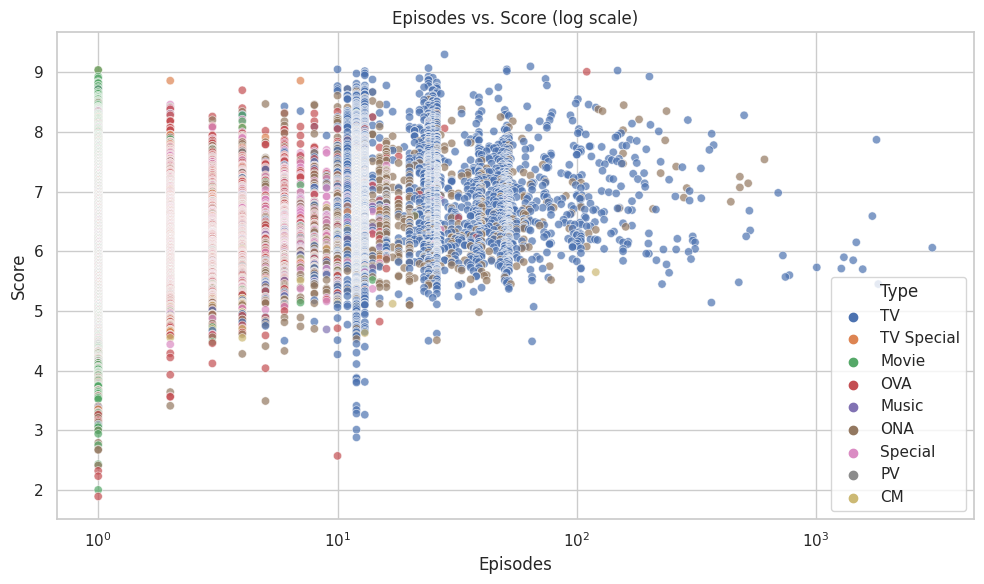

In [15]:
# -------------------- 4. Episodes vs Score --------------------
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='episodes', y='score', hue='type', alpha=0.7)
plt.xscale('log')
plt.title('Episodes vs. Score (log scale)')
plt.xlabel('Episodes')
plt.ylabel('Score')
plt.legend(title='Type')
plt.tight_layout()
plt.show()

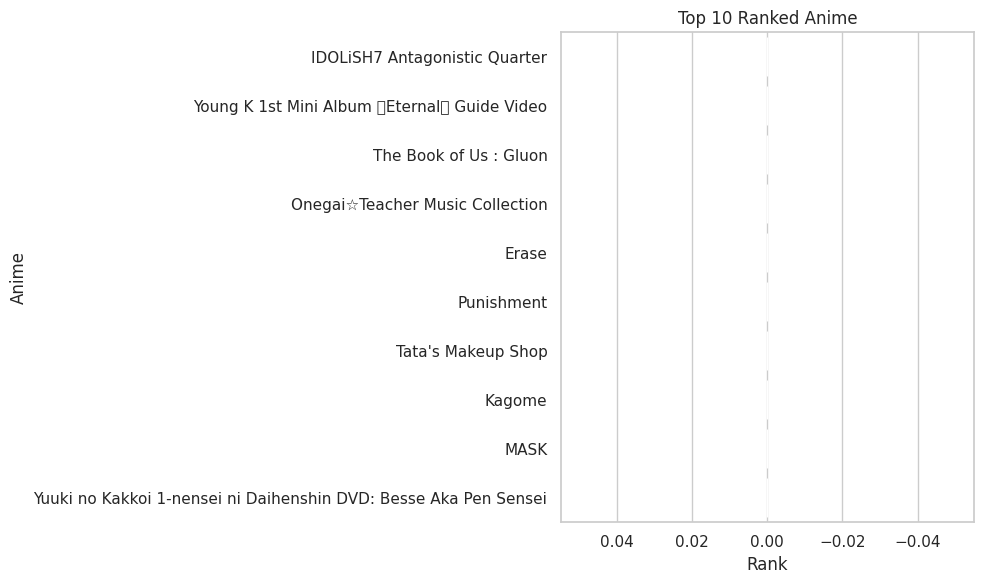

In [16]:
# -------------------- 5. Top 10 Ranked Anime --------------------
top_ranked = df[df['rank'].notna()].sort_values('rank').head(10)

plt.figure(figsize=(10, 6))
sns.barplot(y=top_ranked['name'], x=top_ranked['rank'], palette='viridis')
plt.title('Top 10 Ranked Anime')
plt.xlabel('Rank')
plt.ylabel('Anime')
plt.gca().invert_xaxis()  # So Rank 1 is at top
plt.tight_layout()
plt.show()

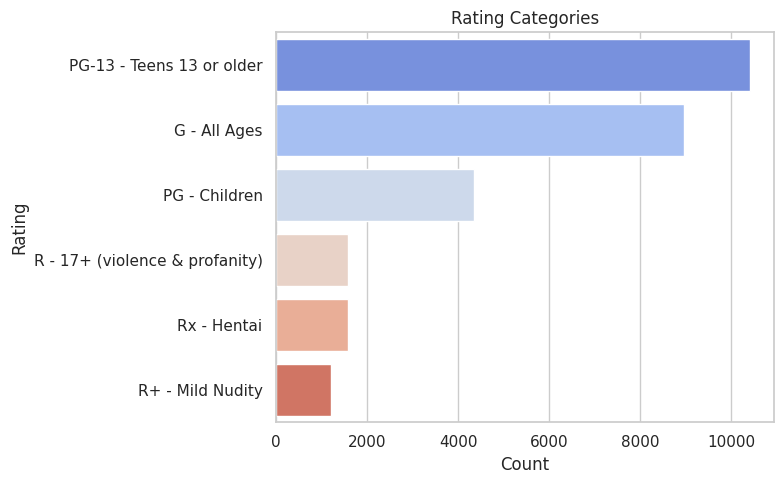

In [17]:
# -------------------- 6. Rating Distribution --------------------
plt.figure(figsize=(8, 5))
sns.countplot(data=df, y='rating', order=df['rating'].value_counts().index, palette='coolwarm')
plt.title('Rating Categories')
plt.xlabel('Count')
plt.ylabel('Rating')
plt.tight_layout()
plt.show()


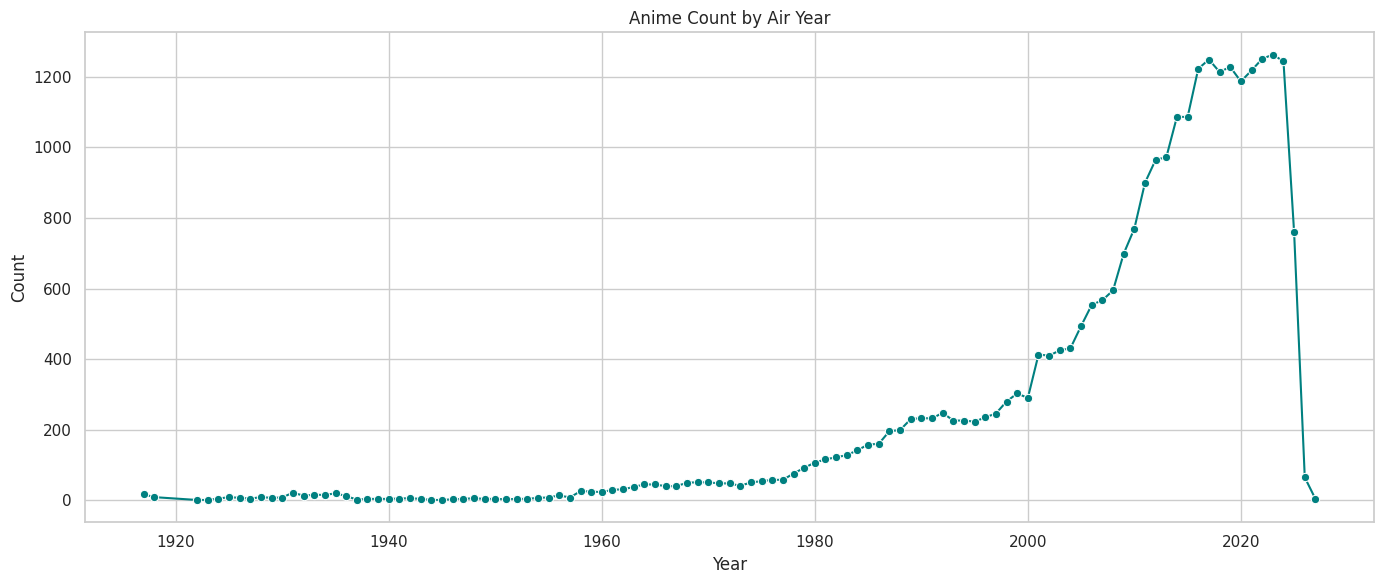

In [18]:
# -------------------- 7. Anime Count by Air Year --------------------
df['aired_from'] = pd.to_datetime(df['aired_from'], errors='coerce')
df['air_year'] = df['aired_from'].dt.year
yearly_counts = df['air_year'].dropna().astype(int).value_counts().sort_index()

plt.figure(figsize=(14, 6))
sns.lineplot(x=yearly_counts.index, y=yearly_counts.values, marker='o', color='teal')
plt.title('Anime Count by Air Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

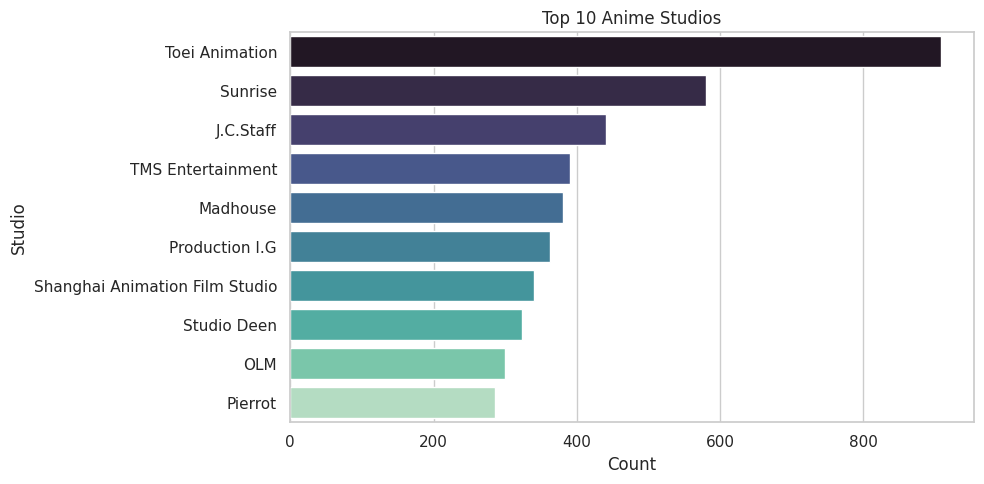

In [19]:
# -------------------- 8. Top 10 Studios --------------------
studio_series = df['studios'].dropna().str.split(', ').explode()
top_studios = studio_series.value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_studios.values, y=top_studios.index, palette='mako')
plt.title('Top 10 Anime Studios')
plt.xlabel('Count')
plt.ylabel('Studio')
plt.tight_layout()
plt.show()


## Predictive modeling

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

In [21]:
# Drop irrelevant columns
df.drop(['id', 'name', 'image', 'trailer', 'synopsis'], axis=1, inplace=True)

# Drop rows where target ('type') is missing
df.dropna(subset=['type'], inplace=True)

# Fill missing values in numerical and categorical features
for col in df.select_dtypes(include=['number']).columns:
    df[col].fillna(df[col].median(), inplace=True)

for col in df.select_dtypes(include=['object']).columns:
    df[col].fillna('Unknown', inplace=True)

In [22]:
# Convert 'aired_from' to year if it exists
if 'aired_from' in df.columns:
    df['aired_from'] = pd.to_datetime(df['aired_from'], errors='coerce')
    df['aired_year'] = df['aired_from'].dt.year.fillna(0).astype(int)
    df.drop(['aired_from', 'aired_to'], axis=1, errors='ignore', inplace=True)
else:
    df['aired_year'] = 0  # Placeholder if column missing


# Label Encoding for categorical columns
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Features and Target
X = df.drop('type', axis=1)
y = df['type']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
# Models to evaluate
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'Support Vector Machine': SVC(),
    'Naive Bayes': GaussianNB()
}

# Train and evaluate
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append((name, round(acc * 100, 2)))

# Show results as DataFrame
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy (%)'])
print(results_df.sort_values(by='Accuracy (%)', ascending=False))

                    Model  Accuracy (%)
2           Random Forest         82.31
3       Gradient Boosting         81.52
1           Decision Tree         76.01
0     Logistic Regression         54.52
5             Naive Bayes         36.33
4  Support Vector Machine         34.50


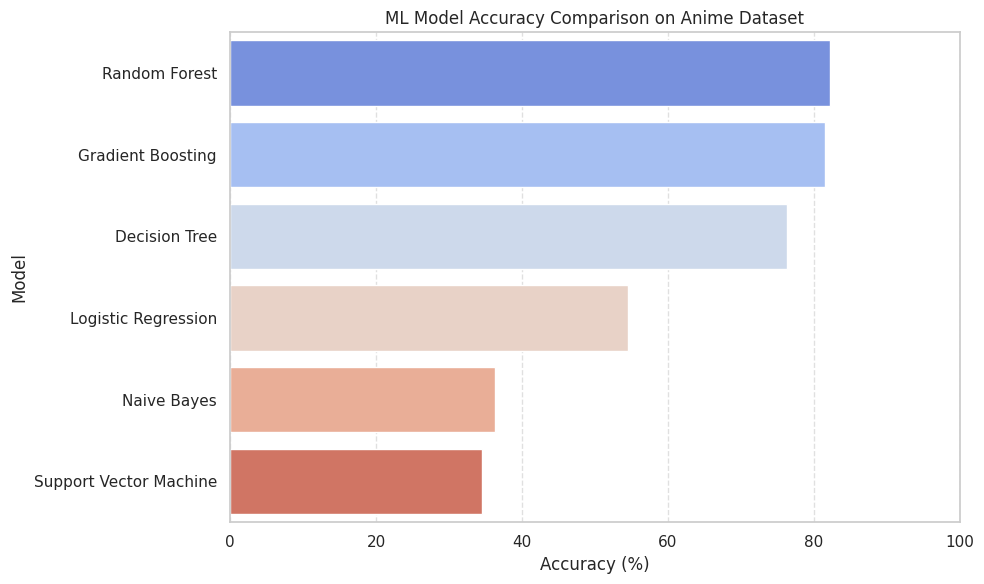

In [24]:
# Accuracy results
results = {
    'Model': [
        'Random Forest',
        'Gradient Boosting',
        'Decision Tree',
        'Logistic Regression',
        'Naive Bayes',
        'Support Vector Machine'
    ],
    'Accuracy (%)': [82.25, 81.51, 76.36, 54.52, 36.33, 34.50]
}

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Sort by accuracy
results_df.sort_values(by='Accuracy (%)', ascending=False, inplace=True)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='Accuracy (%)', y='Model', palette='coolwarm')
plt.title('ML Model Accuracy Comparison on Anime Dataset')
plt.xlabel('Accuracy (%)')
plt.ylabel('Model')
plt.xlim(0, 100)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Thank you..pls upvote!!!!